### Required Assignment 4.3: Data Cleaning

**Expected Time: 120 Minutes**

**Total Points: 40**

This assignment focuses on making decisions with a somewhat dirty dataset.  From datatype conversion to object removal and cleaning to missing value handling, cleaning data will be a regular activity while working with data in the wild.  The dataset comes from Kaggle [here](https://www.kaggle.com/shansh8/companies-info-wikipedia-2021) and represents information on businesses pulled from [dbpedia](http://dbpedia.org) pertaining to business indicators from a variety of international companies.


#### Index:

- [Problem 1](#Problem-1)
- [Problem 2](#Problem-2)
- [Problem 3](#Problem-3)
- [Problem 4](#Problem-4)
- [Problem 5](#Problem-5)
- [Problem 6](#Problem-6)
- [Problem 7](#Problem-7)
- [Problem 8](#Problem-8)
- [Problem 9](#Problem-9)




### Load and Explore the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv('data/biz.zip', compression = 'zip')

In [3]:
df.head()

,a,name,type,foundation,location,products,sector,employee,assets,equity,revenue,profit
0,http://dbpedia.org/resource/Deutsche_EuroShop,Deutsche EuroShop AG,http://dbpedia.org/resource/Aktiengesellschaft,1999,http://dbpedia.org/resource/Germany,Investment in shopping centers,http://dbpedia.org/resource/Real_property,4,2.96E+09,1.25E+09,2.24E+08,8.04E+07
1,http://dbpedia.org/resource/Deutsche_EuroShop,Deutsche EuroShop AG,http://dbpedia.org/resource/Aktiengesellschaft,1999,http://dbpedia.org/resource/Hamburg,Investment in shopping centers,http://dbpedia.org/resource/Real_property,4,2.96E+09,1.25E+09,2.24E+08,8.04E+07
2,http://dbpedia.org/resource/Industry_of_Machin...,Industry of Machinery and Tractors,http://dbpedia.org/resource/Društvo_sa_ogranič...,8/12/1996,http://dbpedia.org/resource/Belgrade,http://dbpedia.org/resource/Tractors,http://dbpedia.org/resource/Agribusiness,4,4.65E+07,0,30000,-€0.47 million
3,http://dbpedia.org/resource/Industry_of_Machin...,Industry of Machinery and Tractors,http://dbpedia.org/resource/Društvo_sa_ogranič...,8/12/1996,http://dbpedia.org/resource/Serbia,http://dbpedia.org/resource/Agricultural_machi...,http://dbpedia.org/resource/Agribusiness,4,4.65E+07,0,30000,-€0.47 million
4,http://dbpedia.org/resource/Industry_of_Machin...,Industry of Machinery and Tractors,http://dbpedia.org/resource/Društvo_sa_ogranič...,8/12/1996,http://dbpedia.org/resource/Belgrade,http://dbpedia.org/resource/Agricultural_machi...,http://dbpedia.org/resource/Agribusiness,4,4.65E+07,0,30000,-€0.47 million


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   a           10000 non-null  str  
 1   name        9969 non-null   str  
 2   type        10000 non-null  str  
 3   foundation  9665 non-null   str  
 4   location    9936 non-null   str  
 5   products    9014 non-null   str  
 6   sector      10000 non-null  str  
 7   employee    10000 non-null  int64
 8   assets      7103 non-null   str  
 9   equity      7124 non-null   str  
 10  revenue     6943 non-null   str  
 11  profit      7107 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.4 MB


<Axes: >

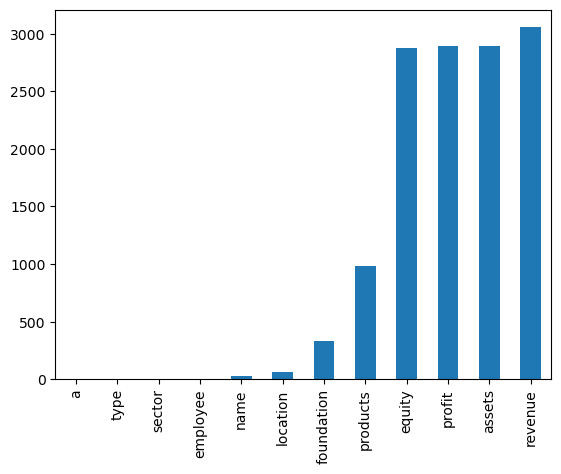

In [8]:
df.isnull().sum().sort_values().plot(kind='bar')

[Back to top](#Index:) 

### Problem 1

#### Plot of Missing Data

**0 Points**

Create a barplot using `matplotlib` with the $x$-axis representing the columns and the $y$-axis representing the count of missing values. Sort these values from least to greatest.  Save your plot in the `images` folder as `missing_plot.png`.  

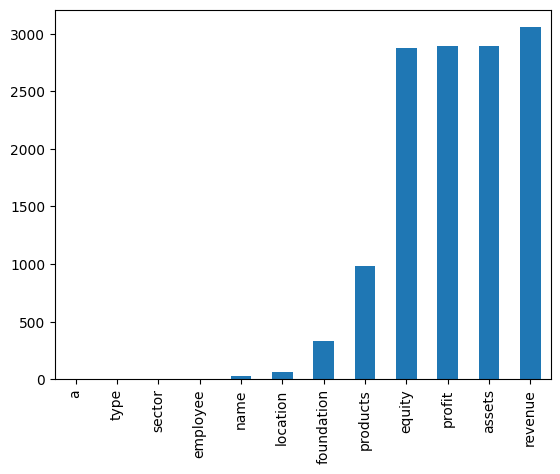

In [7]:
### GRADED

### BEGIN SOLUTION
df.isnull().sum().sort_values().plot(kind = 'bar')
plt.savefig('images/missing_plot_.png')
plt.show()
### END SOLUTION

In [16]:
df[df["name"].isnull()]

,a,name,type,foundation,location,products,sector,employee,assets,equity,revenue,profit
3906,http://dbpedia.org/resource/Royal_Canadian_Mint,NaN,http://dbpedia.org/resource/Crown_corporations...,1/2/1908,520,http://dbpedia.org/resource/Coins,http://dbpedia.org/resource/Mint_(facility),1280,4.44E+08,1.85E+08,"$2,641.4million",2.45E+07
3909,http://dbpedia.org/resource/Royal_Canadian_Mint,NaN,http://dbpedia.org/resource/Crown_corporations...,1/2/1908,"Ottawa, Ontario, Canada",http://dbpedia.org/resource/Coins,http://dbpedia.org/resource/Mint_(facility),1280,4.44E+08,1.85E+08,"$2,641.4million",2.45E+07
4861,http://dbpedia.org/resource/Bulgarian_Postbank,NaN,http://dbpedia.org/resource/Commercial_bank,1991,http://dbpedia.org/resource/Bulgaria,http://dbpedia.org/resource/Asset_management,http://dbpedia.org/resource/Financial_services,3000,6.82E+09,1.15E+09,3.05E+08,1.20E+08
4862,http://dbpedia.org/resource/Bulgarian_Postbank,NaN,http://dbpedia.org/resource/Commercial_bank,1991,http://dbpedia.org/resource/Bulgaria,http://dbpedia.org/resource/Factoring_(finance),http://dbpedia.org/resource/Financial_services,3000,6.82E+09,1.15E+09,3.05E+08,1.20E+08
4863,http://dbpedia.org/resource/Bulgarian_Postbank,NaN,http://dbpedia.org/resource/Commercial_bank,1991,http://dbpedia.org/resource/Bulgaria,http://dbpedia.org/resource/Investment_banking,http://dbpedia.org/resource/Financial_services,3000,6.82E+09,1.15E+09,3.05E+08,1.20E+08
4864,http://dbpedia.org/resource/Bulgarian_Postbank,NaN,http://dbpedia.org/resource/Commercial_bank,1991,http://dbpedia.org/resource/Bulgaria,http://dbpedia.org/resource/Retail_banking,http://dbpedia.org/resource/Financial_services,3000,6.82E+09,1.15E+09,3.05E+08,1.20E+08
4865,http://dbpedia.org/resource/Bulgarian_Postbank,NaN,http://dbpedia.org/resource/Commercial_bank,1991,http://dbpedia.org/resource/Bulgaria,http://dbpedia.org/resource/Corporate_banking,http://dbpedia.org/resource/Financial_services,3000,6.82E+09,1.15E+09,3.05E+08,1.20E+08
4866,http://dbpedia.org/resource/Bulgarian_Postbank,NaN,http://dbpedia.org/resource/Commercial_bank,1991,http://dbpedia.org/resource/Bulgaria,Loans,http://dbpedia.org/resource/Financial_services,3000,6.82E+09,1.15E+09,3.05E+08,1.20E+08
4879,http://dbpedia.org/resource/Bulgarian_Postbank,NaN,http://dbpedia.org/resource/Commercial_bank,1991,http://dbpedia.org/resource/Sofia,http://dbpedia.org/resource/Asset_management,http://dbpedia.org/resource/Financial_services,3000,6.82E+09,1.15E+09,3.05E+08,1.20E+08
4880,http://dbpedia.org/resource/Bulgarian_Postbank,NaN,http://dbpedia.org/resource/Commercial_bank,1991,http://dbpedia.org/resource/Sofia,http://dbpedia.org/resource/Factoring_(finance),http://dbpedia.org/resource/Financial_services,3000,6.82E+09,1.15E+09,3.05E+08,1.20E+08


[Back to top](#Index:) 

### Problem 2

#### `name` column

**5 Points**

The column `name` has 31 missing values.

Subset the data to examine these observations where `name` is missing. Assign the result as a DataFrame to `ans2` below.  

In [20]:
### GRADED

ans2 = None

### BEGIN SOLUTION
ans2 = df.loc[df['name'].isnull()]
### END SOLUTION

# Answer check
print(type(ans2))
ans2.head()

<class 'pandas.DataFrame'>


,a,name,type,foundation,location,products,sector,employee,assets,equity,revenue,profit
3906,http://dbpedia.org/resource/Royal_Canadian_Mint,NaN,http://dbpedia.org/resource/Crown_corporations...,1/2/1908,520,http://dbpedia.org/resource/Coins,http://dbpedia.org/resource/Mint_(facility),1280,4.44E+08,1.85E+08,"$2,641.4million",2.45E+07
3909,http://dbpedia.org/resource/Royal_Canadian_Mint,NaN,http://dbpedia.org/resource/Crown_corporations...,1/2/1908,"Ottawa, Ontario, Canada",http://dbpedia.org/resource/Coins,http://dbpedia.org/resource/Mint_(facility),1280,4.44E+08,1.85E+08,"$2,641.4million",2.45E+07
4861,http://dbpedia.org/resource/Bulgarian_Postbank,NaN,http://dbpedia.org/resource/Commercial_bank,1991,http://dbpedia.org/resource/Bulgaria,http://dbpedia.org/resource/Asset_management,http://dbpedia.org/resource/Financial_services,3000,6.82E+09,1.15E+09,3.05E+08,1.20E+08
4862,http://dbpedia.org/resource/Bulgarian_Postbank,NaN,http://dbpedia.org/resource/Commercial_bank,1991,http://dbpedia.org/resource/Bulgaria,http://dbpedia.org/resource/Factoring_(finance),http://dbpedia.org/resource/Financial_services,3000,6.82E+09,1.15E+09,3.05E+08,1.20E+08
4863,http://dbpedia.org/resource/Bulgarian_Postbank,NaN,http://dbpedia.org/resource/Commercial_bank,1991,http://dbpedia.org/resource/Bulgaria,http://dbpedia.org/resource/Investment_banking,http://dbpedia.org/resource/Financial_services,3000,6.82E+09,1.15E+09,3.05E+08,1.20E+08


[Back to top](#Index:) 

### Problem 3

### Filling Missing Values in `name`

**5 Points**

Examining the rows missing values in names shows that in the adjacent `a` column, the end of the URL contains what can stand in as a name.  Using the `split` string method on the column `a` to split the URL by `/`.  

Assign your split URL's as a series to `ans3` below.

This series will be a collection of lists:

```python
0       [http:, , dbpedia.org, resource, Deutsche_Euro...
1       [http:, , dbpedia.org, resource, Deutsche_Euro...
2       [http:, , dbpedia.org, resource, Industry_of_M...
3       [http:, , dbpedia.org, resource, Industry_of_M...
4       [http:, , dbpedia.org, resource, Industry_of_M...
         .
         .
         .
```



In [21]:
ans2["a"].str.split(pat="/")

3906    [http:, , dbpedia.org, resource, Royal_Canadia...
3909    [http:, , dbpedia.org, resource, Royal_Canadia...
4861    [http:, , dbpedia.org, resource, Bulgarian_Pos...
4862    [http:, , dbpedia.org, resource, Bulgarian_Pos...
4863    [http:, , dbpedia.org, resource, Bulgarian_Pos...
4864    [http:, , dbpedia.org, resource, Bulgarian_Pos...
4865    [http:, , dbpedia.org, resource, Bulgarian_Pos...
4866    [http:, , dbpedia.org, resource, Bulgarian_Pos...
4879    [http:, , dbpedia.org, resource, Bulgarian_Pos...
4880    [http:, , dbpedia.org, resource, Bulgarian_Pos...
4881    [http:, , dbpedia.org, resource, Bulgarian_Pos...
4882    [http:, , dbpedia.org, resource, Bulgarian_Pos...
4883    [http:, , dbpedia.org, resource, Bulgarian_Pos...
4884    [http:, , dbpedia.org, resource, Bulgarian_Pos...
6502    [http:, , dbpedia.org, resource, FirstMerit_Co...
6503    [http:, , dbpedia.org, resource, FirstMerit_Co...
6504    [http:, , dbpedia.org, resource, FirstMerit_Co...
6505    [http:

In [24]:
### GRADED

ans3 = None

### BEGIN SOLUTION
ans3 = df['a'].str.split('/')
### END SOLUTION

# Answer check
print(type(ans3))
ans3.head()

<class 'pandas.Series'>


0    [http:, , dbpedia.org, resource, Deutsche_Euro...
1    [http:, , dbpedia.org, resource, Deutsche_Euro...
2    [http:, , dbpedia.org, resource, Industry_of_M...
3    [http:, , dbpedia.org, resource, Industry_of_M...
4    [http:, , dbpedia.org, resource, Industry_of_M...
Name: a, dtype: object

[Back to top](#Index:) 

### Problem 4

#### Extracting the names

**5 Points**

To extract the last element of this list, use the `.apply` method together with an appropriate `lambda` function to create a series based on the last entry of the above list in each row.  Your results should begin with:

```python
0                        Deutsche_EuroShop
1                        Deutsche_EuroShop
2       Industry_of_Machinery_and_Tractors
3       Industry_of_Machinery_and_Tractors
4       Industry_of_Machinery_and_Tractors
                       ...                
```

Save this series to `ans4` below.

In [33]:
ans3.apply(lambda x: x[len(x)-1])

0                        Deutsche_EuroShop
1                        Deutsche_EuroShop
2       Industry_of_Machinery_and_Tractors
3       Industry_of_Machinery_and_Tractors
4       Industry_of_Machinery_and_Tractors
                       ...                
9995                                    BP
9996                                    BP
9997                                    BP
9998                                    BP
9999                                    BP
Name: a, Length: 10000, dtype: str

In [10]:
### GRADED

ans4 = None

### BEGIN SOLUTION
ans4 = df['a'].str.split('/').apply(lambda x: x[-1])
### END SOLUTION

# Answer check
print(type(ans4))
ans4.head()

<class 'pandas.core.series.Series'>


0                     Deutsche_EuroShop
1                     Deutsche_EuroShop
2    Industry_of_Machinery_and_Tractors
3    Industry_of_Machinery_and_Tractors
4    Industry_of_Machinery_and_Tractors
Name: a, dtype: object

[Back to top](#Index:) 

### Problem 5

#### Filling the Missing Values in `name` 

**5 Points**

The `.fillna` method can accept a series and fill in the missing values based on the matching indices.  


Use the series `ans4` you created in Problem 4 to fill in the missing values in the `name` column. 

Overwrite the earlier column and create a DataFrame with no missing values in the `name` column and assign this new DataFrame to `ans5` below.

In [34]:
### GRADED

ans5 = None

### BEGIN SOLUTION
df['name'] = df['name'].fillna(df['a'].str.split('/').apply(lambda x: x[-1]))
ans5 = df
### END SOLUTION

# Answer check
print(type(ans5))
ans5['name'].isnull().sum()

<class 'pandas.DataFrame'>


np.int64(0)

In [42]:
ans1 = df['a'].str.split('/')
ans2 = ans1.apply(lambda x: x[-1])
print(ans2)
df['name'] = df['name'].fillna(ans2)
print(type(df['name']))
ans5 = df
print(type(ans5))
ans5['name'].isnull().sum()
print(pd.__version__)

0                        Deutsche_EuroShop
1                        Deutsche_EuroShop
2       Industry_of_Machinery_and_Tractors
3       Industry_of_Machinery_and_Tractors
4       Industry_of_Machinery_and_Tractors
                       ...                
9995                                    BP
9996                                    BP
9997                                    BP
9998                                    BP
9999                                    BP
Name: a, Length: 10000, dtype: str
<class 'pandas.Series'>
<class 'pandas.DataFrame'>
3.0.0


[Back to top](#Index:) 

### Problem 6

#### `location` missing values

**5 Points**

Note that the `location` column is still missing data.  The column is supposed to represent the location of the company as a URL in `dbpedia` or, in some cases, simply the name of the city where the company is located.  


Use the `isnull()` function to count how many missing values are in the `location` columns. Next, use the `value_counts()` function on the `foundation` column.  Assign these counts as a series to `ans6` below.

In [43]:
### GRADED

ans6 = None

### BEGIN SOLUTION
ans6 = df[df['location'].isnull()].foundation.value_counts()
### END SOLUTION

# Answer check
print(type(ans6))
ans6.head()

<class 'pandas.Series'>


foundation
4/8/1980                                   34
Colombo, Sri Lanka                         12
9/7/1933                                    6
New Orleans, Louisiana, U.S.                3
Canonsburg, Pennsylvania, United States     2
Name: count, dtype: int64

In [45]:
ans6 = None

### BEGIN SOLUTION
ans5 = df[df['location'].isnull()]
ans6 = ans5['foundation'].value_counts()
### END SOLUTION

# Answer check
print(type(ans6))
ans6.head()

<class 'pandas.Series'>


foundation
4/8/1980                                   34
Colombo, Sri Lanka                         12
9/7/1933                                    6
New Orleans, Louisiana, U.S.                3
Canonsburg, Pennsylvania, United States     2
Name: count, dtype: int64

[Back to top](#Index:) 

### Problem 7

#### Replace missing `location` with `foundation`

**5 Points**

While not perfect, the values in the `foundation` column could serve as a fill-in for the missing values in `location`.  Replace the missing values in `location` with their corresponding value in `foundation`.  Assign the series with the value filled for `location` to `ans7` below.

**HINT**: Check if the values of `location` is missing using `[df['location'].isnull()]` and use `.fillna()` to fill it with `foundation`

In [13]:
### GRADED

ans7 = None

### BEGIN SOLUTION
ans7 = df['location'].fillna(df[df['location'].isnull()]['foundation'])
### END SOLUTION

# Answer check
print(type(ans7))
ans7

<class 'pandas.core.series.Series'>


0        http://dbpedia.org/resource/Germany
1        http://dbpedia.org/resource/Hamburg
2       http://dbpedia.org/resource/Belgrade
3         http://dbpedia.org/resource/Serbia
4       http://dbpedia.org/resource/Belgrade
                        ...                 
9995                     London, England, UK
9996                     London, England, UK
9997                     London, England, UK
9998                     London, England, UK
9999                     London, England, UK
Name: location, Length: 10000, dtype: object

In [55]:
ans7 = None

### BEGIN SOLUTION
a = df[df['location'].isnull()]
ans7 = df['location'].fillna(a['foundation'])
### END SOLUTION

# Answer check
print(type(ans7))
ans7

<class 'pandas.Series'>


0        http://dbpedia.org/resource/Germany
1        http://dbpedia.org/resource/Hamburg
2       http://dbpedia.org/resource/Belgrade
3         http://dbpedia.org/resource/Serbia
4       http://dbpedia.org/resource/Belgrade
                        ...                 
9995                     London, England, UK
9996                     London, England, UK
9997                     London, England, UK
9998                     London, England, UK
9999                     London, England, UK
Name: location, Length: 10000, dtype: str

[Back to top](#Index:) 

### Problem 8

#### Drop rows missing revenue and profit

**5 Points**


Note that the `revenue` and `profit` columns do not have all their values.  


Use the function `dropna()` on `df` to select the non-null entries in the `subset` with columns `revenue` and `profit`.  

Assign your answer as a DataFrame to `ans8` below.

In [14]:
### GRADED

ans8 = None

### BEGIN SOLUTION
ans8 = df.dropna(subset = ['revenue', 'profit'])
### END SOLUTION

# Answer check
print(type(ans8))
ans8.shape

<class 'pandas.core.frame.DataFrame'>


(5204, 12)

[Back to top](#Index:) 

### Problem 9

#### How many rows were lost?

**5 Points**

Compare the shape of the original dataset to your solution in 8.  How many rows were lost dropping the data?  Assign your answer as an integer to `ans9` below.

In [15]:
### GRADED

ans9 = None

### BEGIN SOLUTION
ans9 = df.shape[0] - df.dropna(subset = ['revenue', 'profit']).shape[0]
### END SOLUTION

# Answer check
print(type(ans9))
ans9

<class 'int'>


4796

In [57]:
a = df.dropna(subset = ['revenue', 'profit'])
ans9 = df.shape[0] - a.shape[0]
print(type(ans9))
ans9

<class 'int'>


4796

Note that you've lost almost half of our data dropping missing revenue and profit.  Perhaps a different approach should be considered!  Take some time and examine other missing data in our dataset and some strategies for dealing with it.  If it is possible to keep observations do so.